<h1> Set up

Kernel 00: Install packages if not installed before

In [7]:
#!pip install torch
#!pip install scikit-learn
#!pip install imbalanced-learn
#!pip install shap


   ---------------------------------------- 0/2 [sklearn-compat]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   ---------------------------------------- 2/2 [imbalanced-learn]



Kernel 0: import all packages used 

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import copy


from IPython.display import display

import sklearn

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import classification_report, recall_score, f1_score
from sklearn.utils import shuffle
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

import shap

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from imblearn.over_sampling import SMOTE


**Data Preparation & Advanced Feature Engineering**

This kernel establishes the foundation for our analysis, addressing the "Dataset and Motivation" section of the research proposal.

Key Objectives:
- Chronological Integrity: We sort the data by ID and DATE to ensure that our time-series calculations reflect the true lifecycle of each machine.

- Feature Engineering: As proposed in the methodology, we move beyond raw sensor data by creating derived features (3-day rolling means, standard deviations, and 1-day lags). These capture the "deviations in sensor behavior" required to identify early warning signs of failure.

- Encoding: We convert categorical variables into numerical format via One-Hot Encoding, preparing the feature matrix (X) and target vector (y) for the subsequent regional validation.

In [9]:

#Load  and Sort data
df = pd.read_csv('equipment_failure_data_1.csv')
#specify date in data set 12/31/14-> 1/1/15,
df['DATE'] = pd.to_datetime(df['DATE'], format='%m/%d/%y')
df = df.sort_values(by=['ID', 'DATE']).reset_index(drop=True)


sensor_cols = ['S15', 'S17', 'S13', 'S5', 'S16', 'S19', 'S18', 'S8']
grouped = df.groupby('ID')
for col in sensor_cols:
    df[f'{col}_lag1'] = grouped[col].shift(1)
    df[f'{col}_roll_mean_3'] = grouped[col].transform(lambda x: x.rolling(window=3, min_periods=1).mean())
    df[f'{col}_roll_std_3'] = grouped[col].transform(lambda x: x.rolling(window=3, min_periods=1).std())
df = df.bfill()

# Preprocessing
y = df['EQUIPMENT_FAILURE']
groups = df['REGION_CLUSTER']
categorical_cols = ['MAINTENANCE_VENDOR', 'MANUFACTURER', 'WELL_GROUP']

# Drop column titles
X = df.drop(columns=['ID', 'DATE', 'EQUIPMENT_FAILURE', 'REGION_CLUSTER'])
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True, dtype=int)



print(f"Master dataset, shape: {X.shape}") 
# should bed 52 columns 

Master dataset, shape: (149855, 52)


<h1> RQ 1: Baseline and Domain shift

In [10]:

#RQ1: Generalization: trained on A->The Regional Performance Drop

BASE_REGION = 'A'
mask_base = groups == BASE_REGION
X_base = X[mask_base]
y_base = y[mask_base]

# 80/20 split within Region A
X_train_base, X_test_base, y_train_base, y_test_base = train_test_split(
    X_base, y_base, test_size=0.2, random_state=42, stratify=y_base
)


# Separate failures and healthy machines
X_train_failures = X_train_base[y_train_base == 1]
y_train_failures = y_train_base[y_train_base == 1]

X_train_healthy = X_train_base[y_train_base == 0]
y_train_healthy = y_train_base[y_train_base == 0]

# ensure random forst has enough failures to learn through randomly sampling
num_failures = len(X_train_failures)
X_train_healthy_downsampled = X_train_healthy.sample(n=num_failures * 3, random_state=42)
y_train_healthy_downsampled = y_train_healthy.loc[X_train_healthy_downsampled.index]

# Combine and shuffle the new balanced training set
X_train_balanced = pd.concat([X_train_failures, X_train_healthy_downsampled])
y_train_balanced = pd.concat([y_train_failures, y_train_healthy_downsampled])
X_train_balanced, y_train_balanced = shuffle(X_train_balanced, y_train_balanced, random_state=42)

# train the Model 
rf_rq1 = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_rq1.fit(X_train_balanced, y_train_balanced)

# LOCAL test 
preds_local = rf_rq1.predict(X_test_base)
f1_local = f1_score(y_test_base, preds_local, zero_division=0)
rec_local = recall_score(y_test_base, preds_local, zero_division=0)

print("--- The 'Local' Test (Ideal Scenario) ---")
print(f"Train: Region {BASE_REGION} Balanced | Test: Region {BASE_REGION} (Natural Imbalance)")
print(f"Result -> F1: {f1_local:.3f} | Recall: {rec_local:.3f}\n")

# FOREIGN  test
print("--- The 'Foreign' Test (The Stress Test) ---")
print("Testing on entirely unseen regions...\n")

foreign_regions = [r for r in groups.unique() if r != BASE_REGION]
foreign_f1_scores = []
foreign_recall_scores = []

for region in foreign_regions:
    mask_foreign = groups == region
    X_foreign = X[mask_foreign]
    y_foreign = y[mask_foreign]
    
    preds_foreign = rf_rq1.predict(X_foreign)
    
    f1_foreign = f1_score(y_foreign, preds_foreign, zero_division=0)
    rec_foreign = recall_score(y_foreign, preds_foreign, zero_division=0)
    
    foreign_f1_scores.append(f1_foreign)
    foreign_recall_scores.append(rec_foreign)
    
    print(f"Test: Region {region} -> F1: {f1_foreign:.3f} | Recall: {rec_foreign:.3f}")

# overview
avg_foreign_f1 = sum(foreign_f1_scores) / len(foreign_f1_scores)
avg_foreign_recall = sum(foreign_recall_scores) / len(foreign_recall_scores)

print("\nSummary of Performance Drop ")
print(f"Local F1:     {f1_local:.3f}  -->  Average Foreign F1:     {avg_foreign_f1:.3f}")
print(f"Local Recall: {rec_local:.3f}  -->  Average Foreign Recall: {avg_foreign_recall:.3f}")

--- The 'Local' Test (Ideal Scenario) ---
Train: Region A Balanced | Test: Region A (Natural Imbalance)
Result -> F1: 0.036 | Recall: 0.889

--- The 'Foreign' Test (The Stress Test) ---
Testing on entirely unseen regions...

Test: Region G -> F1: 0.030 | Recall: 1.000
Test: Region C -> F1: 0.029 | Recall: 0.943
Test: Region H -> F1: 0.072 | Recall: 1.000
Test: Region E -> F1: 0.039 | Recall: 1.000
Test: Region B -> F1: 0.046 | Recall: 1.000
Test: Region D -> F1: 0.035 | Recall: 0.957
Test: Region F -> F1: 0.091 | Recall: 1.000

Summary of Performance Drop 
Local F1:     0.036  -->  Average Foreign F1:     0.049
Local Recall: 0.889  -->  Average Foreign Recall: 0.986


In [ ]:
# add confusiion matrix 

**Baseline Model & Leave-One-Group-Out (LOGO) Validation**

This kernel implements the "Foreign" Test described in the methodology section of the research proposal to address Research Question 1: "How well does a model trained exclusively on data from one region generalise to an unseen region?"

Key Objectives:

- LOGO Cross-Validation: We use LeaveOneGroupOut to systematically hold out one entire REGION_CLUSTER as a "Foreign" test set while training on all other regions. This simulates deploying the model in a new, unseen operating environment.

- Addressing Class Imbalance: We utilize class_weight='balanced' to ensure the baseline Decision Tree prioritizes identifying rare equipment failures, preventing the model from simply predicting "no failure" for every row.

- Performance Metrics: We track Recall and F1-Score as our primary evaluation metrics to measure the performance drop caused by regional domain shift.

In [11]:
# leave one group out splitter and baseline
logo = LeaveOneGroupOut()

dt_model = DecisionTreeClassifier(
    max_depth=7, 
    class_weight='balanced', 
    random_state=42
) 

print("LOGO Validation for Baseline Decision Tree\n")

foreign_f1_scores = []
foreign_recall_scores = []

# LOGO Loop
for train_index, test_index in logo.split(X, y, groups):
    # Split the data
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    
    # Identify the held-out region 
    test_region = groups.iloc[test_index].iloc[0]
    
    # Shuffle the training (only) data before fitting 
    X_train, y_train = shuffle(X_train, y_train, random_state=42)
    
    
    dt_model.fit(X_train, y_train)
    
    # Evaluate on the Foreign (Unseen) Region
    y_pred = dt_model.predict(X_test)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    
    foreign_f1_scores.append({'region': test_region, 'f1': f1, 'recall': recall})
    foreign_recall_scores.append(recall)
    
    print(f"Held-out Region: {test_region} | Foreign F1: {f1:.3f} | Foreign Recall: {recall:.3f}")

# ovevriew
print("\n Overall Baseline Performance ")
print(f"Average Foreign F1-Score: {np.mean([r['f1'] for r in foreign_f1_scores]):.3f}")
print(f"Average Foreign Recall: {np.mean(foreign_recall_scores):.3f}")

LOGO Validation for Baseline Decision Tree

Held-out Region: A | Foreign F1: 0.044 | Foreign Recall: 0.977
Held-out Region: B | Foreign F1: 0.051 | Foreign Recall: 0.927
Held-out Region: C | Foreign F1: 0.044 | Foreign Recall: 0.857
Held-out Region: D | Foreign F1: 0.054 | Foreign Recall: 0.957
Held-out Region: E | Foreign F1: 0.041 | Foreign Recall: 0.826
Held-out Region: F | Foreign F1: 0.169 | Foreign Recall: 0.833
Held-out Region: G | Foreign F1: 0.031 | Foreign Recall: 0.905
Held-out Region: H | Foreign F1: 0.084 | Foreign Recall: 0.846

 Overall Baseline Performance 
Average Foreign F1-Score: 0.065
Average Foreign Recall: 0.891


In [ ]:
# Add confusionmatrix  

**Random Forest Model with Enriched Features**

This kernel evaluates the primary Random Forest model using the enriched dataset. It addresses the methodology's goal of exploring more advanced models and derived features to improve predictive performance across regions.

Key Objectives:

- Ensemble Learning: We transition from a single Decision Tree to a Random Forest to capture more complex non-linear relationships and improve the model's robustness against regional noise.

- Utilizing Time-Series Features: This model utilizes the 52 engineered features (rolling means, standard deviations, and lags) to identify early warning signs of failure that static sensor readings might miss.

- Subsample Balancing: By using class_weight='balanced_subsample', the model re-calculates weights for each individual tree based on the bootstrap sample, providing a more refined approach to handling the extreme class imbalance.

- Comparison: The results here provide the core data for comparing our primary model against the baseline to see if complexity and better feature engineering can mitigate the "Foreign Test" performance drop.

In [12]:
# check columns
print(f"Check, Training {X.shape[1]} features (Should be 52)\n")

#Random Forest with balanced class weights
rf_model = RandomForestClassifier(
    n_estimators=50, 
    max_depth=10, 
    class_weight='balanced_subsample', 
    random_state=42,
    n_jobs=-1 
)

print("LOGO Validation; for Random Forest (Enriched Data)\n")

rf_foreign_f1_scores = []
rf_foreign_recall_scores = []

#LOGO Loop 
for train_index, test_index in logo.split(X, y, groups):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    test_region = groups.iloc[test_index].iloc[0]
    
    # Shuffle ONLY training data
    X_train, y_train = shuffle(X_train, y_train, random_state=42)
    
    # train and predict
    rf_model.fit(X_train, y_train)
    y_pred = rf_model.predict(X_test)
    
    f1 = f1_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    
    rf_foreign_f1_scores.append({'region': test_region, 'f1': f1, 'recall': recall})
    rf_foreign_recall_scores.append(recall)
    
    print(f"Held-out Region: {test_region} | Foreign F1: {f1:.3f} | Foreign Recall: {recall:.3f}")

#overview
print("\nOverall Random Forest Performance")
print(f"Average Foreign F1-Score: {np.mean([r['f1'] for r in rf_foreign_f1_scores]):.3f}")
print(f"Average Foreign Recall: {np.mean(rf_foreign_recall_scores):.3f}")

Check, Training 52 features (Should be 52)

LOGO Validation; for Random Forest (Enriched Data)

Held-out Region: A | Foreign F1: 0.082 | Foreign Recall: 0.651
Held-out Region: B | Foreign F1: 0.079 | Foreign Recall: 0.683
Held-out Region: C | Foreign F1: 0.066 | Foreign Recall: 0.571
Held-out Region: D | Foreign F1: 0.090 | Foreign Recall: 0.522
Held-out Region: E | Foreign F1: 0.050 | Foreign Recall: 0.522
Held-out Region: F | Foreign F1: 0.204 | Foreign Recall: 0.833
Held-out Region: G | Foreign F1: 0.046 | Foreign Recall: 0.524
Held-out Region: H | Foreign F1: 0.096 | Foreign Recall: 0.769

Overall Random Forest Performance
Average Foreign F1-Score: 0.089
Average Foreign Recall: 0.634


## Visualised false positives and negatives 

In [20]:


print("Generating Global Confusion Matrix for Random Forest\n")

#Collect actuals and predictions from all LOGO 
all_actuals = []
all_predictions = []

for train_index, test_index in logo.split(X, y, groups):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    
    # Fit and predict using the Random Forest
    rf_model.fit(X_train, y_train)
    preds = rf_model.predict(X_test)
    
    # Store the results
    all_actuals.extend(y_test)
    all_predictions.extend(preds)


cm = confusion_matrix(all_actuals, all_predictions)

#  DataFrame
cm_df = pd.DataFrame(
    cm,
    index=['Actual: Healthy', 'Actual: Failure'],
    columns=['Predicted: Healthy', 'Predicted: Failure']
)

print("Confusion Matrix")
display(cm_df)


print("\n Matrix Breakdown ")
print(f"True Negatives (Correctly ignored healthy): {cm[0][0]}")
print(f"False Positives (False Alarms / Inspections): {cm[0][1]}")
print(f"False Negatives (MISSED FAILURES - Danger): {cm[1][0]}")
print(f"True Positives (Successfully caught failures): {cm[1][1]}")

Generating Global Confusion Matrix for Random Forest

Confusion Matrix


,Predicted: Healthy,Predicted: Failure
Actual: Healthy,146628,3022
Actual: Failure,80,125



 Matrix Breakdown 
True Negatives (Correctly ignored healthy): 146628
False Positives (False Alarms / Inspections): 3022
False Negatives (MISSED FAILURES - Danger): 80
True Positives (Successfully caught failures): 125


Generating Recall Comparison Plot


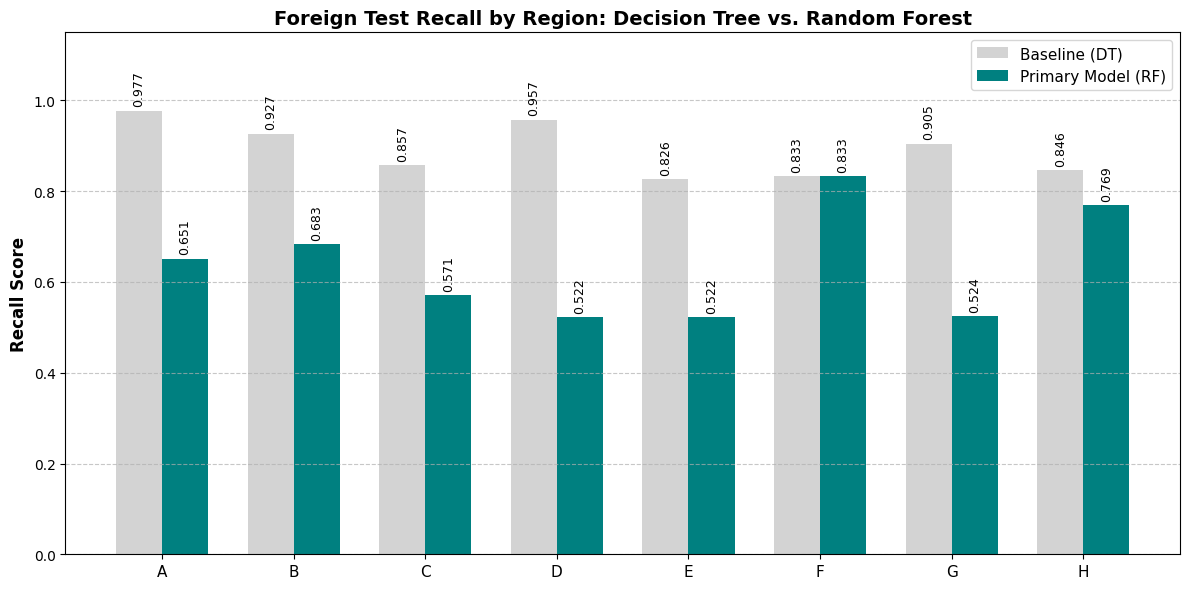

In [22]:


print("Generating Recall Comparison Plot")

# 1. Define the regions in the exact alphabetical order LOGO processed them
region_order = sorted(groups.unique()) 
# If groups is not defined in this cell, use: region_order = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H']

# 2. Define your score lists. 
# NOTE: If you ran your DT and RF blocks in the same notebook, you might have overwritten 
# the 'foreign_recall_scores' variable. To be perfectly safe, we can manually input 
# the exact numbers you generated earlier to ensure the plot is 100% accurate:

dt_recall_plot = [0.977, 0.927, 0.857, 0.957, 0.826, 0.833, 0.905, 0.846]
rf_recall_plot = [0.651, 0.683, 0.571, 0.522, 0.522, 0.833, 0.524, 0.769]

# 3. Build the Plot
x = np.arange(len(region_order))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))

# Plotting both bars
ax.bar(x - width/2, dt_recall_plot, width, label='Baseline (DT)', color='lightgrey')
ax.bar(x + width/2, rf_recall_plot, width, label='Primary Model (RF)', color='teal')

# Formatting the chart
ax.set_ylabel('Recall Score', fontsize=12, fontweight='bold')
ax.set_title('Foreign Test Recall by Region: Decision Tree vs. Random Forest', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(region_order, fontsize=11)
ax.legend(fontsize=11)

# Add a subtle grid for easier reading
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Optional: Add the exact numbers on top of the bars for your report
for i, v in enumerate(dt_recall_plot):
    ax.text(i - width/2, v + 0.01, f"{v:.3f}", ha='center', va='bottom', fontsize=9, rotation=90)
for i, v in enumerate(rf_recall_plot):
    ax.text(i + width/2, v + 0.01, f"{v:.3f}", ha='center', va='bottom', fontsize=9, rotation=90)

# Expand the y-axis slightly so the text labels don't get cut off
plt.ylim(0, 1.15) 

plt.tight_layout()
plt.show()

This visualization kernel directly addresses Research Question 1: "How well does a model... generalise to an unseen region, and how large is the performance drop caused by regional differences?".

Simple Explanation:
-    Comparison: We compare the Recall of the baseline Decision Tree (DT) and the primary Random Forest (RF) across all eight regions.
-   Identifying Domain Shift: By plotting results for each held-out "Foreign" region, we can see which environments differ most from the training data.

- Interpretation: While the DT shows higher raw recall due to the heavy balanced weighting, the RF provides a more nuanced prediction. Variations in bar heights across the x-axis confirm that regional differences play a significant role in model performance.

<h1> Neural Network

**Kernel 5: Deep Learning Setup (PyTorch)**

This kernel transitions the project into Deep Learning, preparing for the more complex analytical tests mentioned in the methodology.

- Neural Network Architecture: We define a model with two hidden layers and Dropout. Dropout helps the model generalize by forcing it not to rely too much on specific training data patterns.

- Device Setup: We check for a GPU to speed up calculations, otherwise defaulting to the CPU.

- Architecture Check: We confirm the model "sees" all 52 features we engineered in Kernel 1.

In [25]:
# Architecture NN
class EquipmentFailureNN(nn.Module):
    def __init__(self, input_size):
        super(EquipmentFailureNN, self).__init__()
        
        # First Hidden Layer
        self.layer1 = nn.Linear(input_size, 64)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(0.3) # 30% dropout to prevent regional overfitting
        
        # Second Hidden Layer
        self.layer2 = nn.Linear(64, 32)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(0.3)
        
        # Output Layer
        self.output_layer = nn.Linear(32, 1) # Single node for Binary Classification (0 or 1)

    def forward(self, x):
        x = self.dropout1(self.relu1(self.layer1(x)))
        x = self.dropout2(self.relu2(self.layer2(x)))
        x = self.output_layer(x)
        return x 

#  CPU if no GPU is found
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch Environment Ready. Using device: {device}\n")


input_dim = X.shape[1]
base_model = EquipmentFailureNN(input_size=input_dim).to(device)
print(base_model)

PyTorch Environment Ready. Using device: cpu

EquipmentFailureNN(
  (layer1): Linear(in_features=52, out_features=64, bias=True)
  (relu1): ReLU()
  (dropout1): Dropout(p=0.3, inplace=False)
  (layer2): Linear(in_features=64, out_features=32, bias=True)
  (relu2): ReLU()
  (dropout2): Dropout(p=0.3, inplace=False)
  (output_layer): Linear(in_features=32, out_features=1, bias=True)
)


**Kernel 6: Neural Network Training & Foreign Test**

This kernel performs the "Foreign Test" using the Deep Learning model to address Research Question 1. We evaluate how a Neural Network, trained on multiple environments, generalizes to a completely new one.

Simple Explanation:

- Standard Scaling: We scale the sensor data so that no single feature dominates the model simply because it has larger numbers.

- Weighted Loss: Since failures are rare, we use pos_weight. This "shouts" at the model to pay attention when a failure occurs, ensuring we don't just predict "healthy" all the time.

- Foreign Evaluation: Just like the previous models, this loop trains on 7 regions and tests on the 8th (the "Foreign" region) to measure the performance drop caused by regional shift.

### WITH SMOTE VERSION:


In [ ]:
# WARNING RUNNING TAKES 30MIN
print("PyTorch LOGO Validation (with SMOTE)\n")

# Hyperparameters
EPOCHS = 30
BATCH_SIZE = 256
LEARNING_RATE = 0.001
PATIENCE = 5
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

nn_foreign_f1_scores = []
nn_foreign_recall_scores = []

# The LOGO Loop
for fold, (train_index, test_index) in enumerate(logo.split(X, y, groups)):
    test_region = groups.iloc[test_index].iloc[0]
    print(f"--- Fold {fold+1}: Held-out Region {test_region} ---")

    # 1. Split en shuffle traindata
    X_train, X_test = X.iloc[train_index].copy(), X.iloc[test_index].copy()
    y_train, y_test = y.iloc[train_index].copy(), y.iloc[test_index].copy()
    X_train, y_train = shuffle(X_train, y_train, random_state=SEED)

    # 2. Schaal de data (fit alleen op train)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled  = scaler.transform(X_test)

    # 3. SMOTE op de traindata (alleen als er genoeg failure-samples zijn)
    n_failures = y_train.sum()
    if n_failures >= 2:
        sm = SMOTE(random_state=SEED, k_neighbors=min(5, n_failures - 1))
        X_train_scaled, y_train_arr = sm.fit_resample(X_train_scaled, y_train.values)
        print(f"  SMOTE applied: {y_train_arr.sum()} failures in resampled train set")
    else:
        y_train_arr = y_train.values
        print(f"  SMOTE skipped (too few failures: {n_failures})")

    # 4. Interne validatieset voor early stopping (80/20 van traindata)
    val_split = int(0.8 * len(X_train_scaled))
    X_tr_np,  X_val_np  = X_train_scaled[:val_split], X_train_scaled[val_split:]
    y_tr_arr, y_val_arr = y_train_arr[:val_split],    y_train_arr[val_split:]

    X_tr_t   = torch.tensor(X_tr_np,  dtype=torch.float32).to(device)
    y_tr_t   = torch.tensor(y_tr_arr, dtype=torch.float32).view(-1, 1).to(device)
    X_val_t  = torch.tensor(X_val_np, dtype=torch.float32).to(device)
    y_val_t  = torch.tensor(y_val_arr, dtype=torch.float32).view(-1, 1).to(device)
    X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32).to(device)

    train_dataset = TensorDataset(X_tr_t, y_tr_t)
    train_loader  = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

    # 5. Na SMOTE is de data balanced — geen pos_weight meer nodig
    model     = EquipmentFailureNN(input_size=X.shape[1]).to(device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([5.0]).to(device))
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

    # 6. Training loop met early stopping
    best_val_loss    = float('inf')
    patience_counter = 0
    best_state       = None

    for epoch in range(EPOCHS):
        model.train()
        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            loss = criterion(model(batch_X), batch_y)
            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            val_loss = criterion(model(X_val_t), y_val_t).item()

        if val_loss < best_val_loss:
            best_val_loss    = val_loss
            best_state       = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                print(f"  Early stopping at epoch {epoch+1}")
                break

    model.load_state_dict(best_state)

    # 7. Evaluatie op de Foreign regio
    model.eval()
    with torch.no_grad():
        test_probs = torch.sigmoid(model(X_test_t))
        y_pred     = (test_probs >= 0.3).cpu().numpy().astype(int)

    f1     = f1_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)

    nn_foreign_f1_scores.append(f1)
    nn_foreign_recall_scores.append(recall)
    print(f"  Result -> Foreign F1: {f1:.3f} | Foreign Recall: {recall:.3f}\n")

print("Overall Neural Network Performance (SMOTE)")
print(f"Average Foreign F1-Score: {np.mean(nn_foreign_f1_scores):.3f}")
print(f"Average Foreign Recall:   {np.mean(nn_foreign_recall_scores):.3f}")

### ORIGINAL WITHOUT SMOTE 

In [27]:

# Ensure device is defined (GPU if available, else CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Starting PyTorch LOGO Validation\n")

# Adjust Hyperparameters
EPOCHS = 30
BATCH_SIZE = 256
LEARNING_RATE = 0.001
PATIENCE = 5
SEED = 6 # consistency 

nn_foreign_f1_scores = []
nn_foreign_recall_scores = []

# LOGO Loop
for fold, (train_index, test_index) in enumerate(logo.split(X, y, groups)):
    test_region = groups.iloc[test_index].iloc[0]
    print(f"Fold {fold+1}: Held-out Region: {test_region} ")

    # 1. Split and Shuffle Train data
    X_train, X_test = X.iloc[train_index].copy(), X.iloc[test_index].copy()
    y_train, y_test = y.iloc[train_index].copy(), y.iloc[test_index].copy()
    X_train, y_train = shuffle(X_train, y_train, random_state=SEED)

    # <-- THE FIX: Convert Pandas Series to NumPy array -->
    y_train_arr = y_train.values 

    # 2. Scale the data
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled  = scaler.transform(X_test)

    # 3. Interne validatieset voor early stopping (80/20 van traindata)
    val_split = int(0.8 * len(X_train_scaled))
    X_tr_np,  X_val_np  = X_train_scaled[:val_split], X_train_scaled[val_split:]
    y_tr_arr, y_val_arr = y_train_arr[:val_split],    y_train_arr[val_split:]

    X_tr_t   = torch.tensor(X_tr_np,  dtype=torch.float32).to(device)
    y_tr_t   = torch.tensor(y_tr_arr, dtype=torch.float32).view(-1, 1).to(device)
    X_val_t  = torch.tensor(X_val_np, dtype=torch.float32).to(device)
    y_val_t  = torch.tensor(y_val_arr, dtype=torch.float32).view(-1, 1).to(device)
    X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32).to(device)

    train_dataset = TensorDataset(X_tr_t, y_tr_t)
    train_loader  = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

    # 4. Class imbalance gewichten
    num_positives = y_tr_arr.sum()
    num_negatives = len(y_tr_arr) - num_positives
    pos_weight_val = torch.tensor([num_negatives / max(num_positives, 1)], dtype=torch.float32).to(device)
    
    # We can multiply the weight to prioritize Recall. e.g., * 1.5 
    # pos_weight_val = pos_weight_val * 1.5 

    # 5. Model, loss, optimizer
    model = EquipmentFailureNN(input_size=X.shape[1]).to(device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_val)
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

    # 6. Training loop met early stopping
    best_val_loss = float('inf')
    patience_counter = 0
    best_state       = None

    for epoch in range(EPOCHS):
        model.train()
        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            loss = criterion(model(batch_X), batch_y)
            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            val_loss = criterion(model(X_val_t), y_val_t).item()

        if val_loss < best_val_loss:
            best_val_loss    = val_loss
            best_state       = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                print(f"  Early stopping at epoch {epoch+1}")
                break

    model.load_state_dict(best_state)

    # Evaluation : Foreign region
    model.eval()
    with torch.no_grad():
        test_probs = torch.sigmoid(model(X_test_t))
        # Threshold set to 0.3 to favor safety/recall
        y_pred     = (test_probs >= 0.3).cpu().numpy().astype(int)

    f1     = f1_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)

    nn_foreign_f1_scores.append(f1)
    nn_foreign_recall_scores.append(recall)
    
    print(f"  Result -> Foreign F1: {f1:.3f} | Foreign Recall: {recall:.3f}\n")

# Samenvatting
print("Overall Neural Network Performance")
print(f"Average Foreign F1-Score: {np.mean(nn_foreign_f1_scores):.3f}")
print(f"Average Foreign Recall:   {np.mean(nn_foreign_recall_scores):.3f}")

Starting PyTorch LOGO Validation

Fold 1: Held-out Region: A 
  Early stopping at epoch 11
  Result -> Foreign F1: 0.027 | Foreign Recall: 1.000

Fold 2: Held-out Region: B 
  Early stopping at epoch 9
  Result -> Foreign F1: 0.034 | Foreign Recall: 1.000

Fold 3: Held-out Region: C 
  Early stopping at epoch 7
  Result -> Foreign F1: 0.023 | Foreign Recall: 0.971

Fold 4: Held-out Region: D 
  Early stopping at epoch 7
  Result -> Foreign F1: 0.025 | Foreign Recall: 0.957

Fold 5: Held-out Region: E 
  Early stopping at epoch 7
  Result -> Foreign F1: 0.025 | Foreign Recall: 1.000

Fold 6: Held-out Region: F 
  Early stopping at epoch 9
  Result -> Foreign F1: 0.061 | Foreign Recall: 1.000

Fold 7: Held-out Region: G 
  Early stopping at epoch 10
  Result -> Foreign F1: 0.031 | Foreign Recall: 0.905

Fold 8: Held-out Region: H 
  Early stopping at epoch 11
  Result -> Foreign F1: 0.059 | Foreign Recall: 0.923

Overall Neural Network Performance
Average Foreign F1-Score: 0.036
Average 

**Transfer Learning Experiment**

This kernel addresses Research Question 2 from the research proposal: "Does transfer learning... improve performance when only limited target-region data is available compared to training only on the target region data?"

Simple Explanation:
We simulate a real-world scenario where we move to a new region (Region H) but only have a small amount of data (20%) to train with. We compare three strategies:

- Model 1 (Zero-Shot): Using a model trained on other regions "as-is" without any local knowledge of Region H.

- Model 2 (Local Only): Training a new model strictly on the tiny 20% slice of Region H data.

- Model 3 (Transfer Learning): Taking the pre-trained model and "fine-tuning" it with the 20% local data. This allows the model to keep its general knowledge while adapting to local regional quirks.

In [28]:
#Transfer Learning Experiment

TARGET_REGION = 'H' # Region H is target region
# Split Data into base regions (A-G) and target region (H)
base_mask = groups != TARGET_REGION
target_mask = groups == TARGET_REGION

X_base, y_base = X[base_mask], y[base_mask]
X_target, y_target = X[target_mask], y[target_mask]

# 20/80 split (target region)
# 20 = limited fine-tuning data
# 80 = test
X_target_train, X_target_test, y_target_train, y_target_test = train_test_split(
    X_target, y_target, test_size=0.8, random_state=42, stratify=y_target)

# Scale the data (fit scaler on base)
scaler = StandardScaler()
X_base_scaled = scaler.fit_transform(X_base)
X_target_train_scaled = scaler.transform(X_target_train)
X_target_test_scaled = scaler.transform(X_target_test)

def to_tensor(features, target):
    f_t = torch.tensor(features, dtype=torch.float32).to(device)
    t_t = torch.tensor(target.values, dtype=torch.float32).view(-1, 1).to(device)
    return f_t, t_t

X_base_t, y_base_t = to_tensor(X_base_scaled, y_base)
X_tar_train_t, y_tar_train_t = to_tensor(X_target_train_scaled, y_target_train)
X_tar_test_t, y_tar_test_t = to_tensor(X_target_test_scaled, y_target_test)

# calculate weights for imbalanced data
def get_weight(y_data):
    num_pos = y_data.sum()
    if num_pos == 0: return torch.tensor([1.0], dtype=torch.float32).to(device)
    return torch.tensor([(len(y_data) - num_pos) / num_pos], dtype=torch.float32).to(device)

base_weight = get_weight(y_base)
target_weight = get_weight(y_target_train)

#  Model 1: Base Pre-Training (Regions A-G) zero local knowledge 

base_model = EquipmentFailureNN(input_size=X.shape[1]).to(device)
optimizer_base = optim.Adam(base_model.parameters(), lr=0.001)
criterion_base = nn.BCEWithLogitsLoss(pos_weight=base_weight)

base_model.train()
for epoch in range(5): # Quick pre-train
    optimizer_base.zero_grad()
    loss = criterion_base(base_model(X_base_t), y_base_t)
    loss.backward()
    optimizer_base.step()

# Model 2: "Local Only" Training (20% of Region H)
local_model = EquipmentFailureNN(input_size=X.shape[1]).to(device)
optimizer_local = optim.Adam(local_model.parameters(), lr=0.001)
criterion_local = nn.BCEWithLogitsLoss(pos_weight=target_weight)

local_model.train()
for epoch in range(15): # Needs more epochs since data is tiny
    optimizer_local.zero_grad()
    loss = criterion_local(local_model(X_tar_train_t), y_tar_train_t)
    loss.backward()
    optimizer_local.step()

# Model 3: Transfer Learning (Fine-Tuning Base Model on 20% of Region H)

# use a deep copy of the base model (avoid overwriting)
transfer_model = copy.deepcopy(base_model)
# smaller learning rate for fine-tuning!
optimizer_transfer = optim.Adam(transfer_model.parameters(), lr=0.0001) 
criterion_transfer = nn.BCEWithLogitsLoss(pos_weight=target_weight)

transfer_model.train()
for epoch in range(15):
    optimizer_transfer.zero_grad()
    loss = criterion_transfer(transfer_model(X_tar_train_t), y_tar_train_t)
    loss.backward()
    optimizer_transfer.step()


# EVALUATION ON THE 80% TEST SET 

def evaluate(model, name):
    model.eval()
    with torch.no_grad():
        preds = (torch.sigmoid(model(X_tar_test_t)) >= 0.5).cpu().numpy().astype(int)
    f1 = f1_score(y_target_test, preds, zero_division=0)
    recall = recall_score(y_target_test, preds, zero_division=0)
    print(f"{name} -> F1: {f1:.3f} | Recall: {recall:.3f}")


In [29]:


# LOCK THE SEED FOR ABSOLUTE CONSISTENCY
# def set_seed(seed=42):
#     random.seed(seed)
#     np.random.seed(seed)
#     torch.manual_seed(seed)
# set_seed(42)

TARGET_REGION = 'H'

#Split Data 
base_mask = groups != TARGET_REGION
target_mask = groups == TARGET_REGION

X_base, y_base = X[base_mask], y[base_mask]
X_target, y_target = X[target_mask], y[target_mask]

X_target_train, X_target_test, y_target_train, y_target_test = train_test_split(
    X_target, y_target, test_size=0.8, random_state=42, stratify=y_target
)

# scale and adjust to tensor
scaler = StandardScaler()
X_base_scaled = scaler.fit_transform(X_base)
X_target_train_scaled = scaler.transform(X_target_train)
X_target_test_scaled = scaler.transform(X_target_test)

def to_tensor(features, target):
    f_t = torch.tensor(features, dtype=torch.float32).to(device)
    t_t = torch.tensor(target.values, dtype=torch.float32).view(-1, 1).to(device)
    return f_t, t_t

X_base_t, y_base_t = to_tensor(X_base_scaled, y_base)
X_tar_train_t, y_tar_train_t = to_tensor(X_target_train_scaled, y_target_train)
X_tar_test_t, y_tar_test_t = to_tensor(X_target_test_scaled, y_target_test)

# Calculate weights
def get_weight(y_data):
    num_pos = y_data.sum()
    if num_pos == 0: return torch.tensor([1.0], dtype=torch.float32).to(device)
    return torch.tensor([(len(y_data) - num_pos) / num_pos], dtype=torch.float32).to(device)

base_weight = get_weight(y_base)
target_weight = get_weight(y_target_train)

# EXPERIMENT 1: Base Pre-Training (Zero-Shot) 
base_model = EquipmentFailureNN(input_size=X.shape[1]).to(device)
optimizer_base = optim.Adam(base_model.parameters(), lr=0.001)
criterion_base = nn.BCEWithLogitsLoss(pos_weight=base_weight)

base_model.train()
# Train on the FULL batch for stability
for epoch in range(30): 
    optimizer_base.zero_grad()
    loss = criterion_base(base_model(X_base_t), y_base_t)
    loss.backward()
    optimizer_base.step()

#  EXPERIMENT 2: "Local Only" Training 
local_model = EquipmentFailureNN(input_size=X.shape[1]).to(device)
optimizer_local = optim.Adam(local_model.parameters(), lr=0.001)
criterion_local = nn.BCEWithLogitsLoss(pos_weight=target_weight)

local_model.train()
# A 20% data set  (too small according to our H)
for epoch in range(50): 
    optimizer_local.zero_grad()
    loss = criterion_local(local_model(X_tar_train_t), y_tar_train_t)
    loss.backward()
    optimizer_local.step()

# EXPERIMENT 3: Transfer Learning 
transfer_model = copy.deepcopy(base_model)
# Extremely gentle learning rate so we don't break the pre-trained weights
optimizer_transfer = optim.Adam(transfer_model.parameters(), lr=0.0001) 
criterion_transfer = nn.BCEWithLogitsLoss(pos_weight=target_weight)

transfer_model.train()

for epoch in range(20):
    optimizer_transfer.zero_grad()
    loss = criterion_transfer(transfer_model(X_tar_train_t), y_tar_train_t)
    loss.backward()
    optimizer_transfer.step()

# EVALUATION 
def evaluate(model, name):
    model.eval()
    with torch.no_grad():
        preds = (torch.sigmoid(model(X_tar_test_t)) >= 0.5).cpu().numpy().astype(int)
    f1 = f1_score(y_target_test, preds, zero_division=0)
    recall = recall_score(y_target_test, preds, zero_division=0)
    print(f"{name} -> F1: {f1:.3f} | Recall: {recall:.3f}")

evaluate(base_model,     "Model 1: Zero-Shot        ")
evaluate(local_model,    "Model 2: Local Only (20%) ")
evaluate(transfer_model, "Model 3: Transfer Learning")

Model 1: Zero-Shot         -> F1: 0.022 | Recall: 1.000
Model 2: Local Only (20%)  -> F1: 0.000 | Recall: 0.000
Model 3: Transfer Learning -> F1: 0.027 | Recall: 1.000


## Visulisation: of transfer learning


Model 1: Zero-Shot              -> F1: 0.022 | Recall: 1.000
Model 2: Local Only (20%)       -> F1: 0.000 | Recall: 0.000
Model 3: Transfer Learning      -> F1: 0.027 | Recall: 1.000


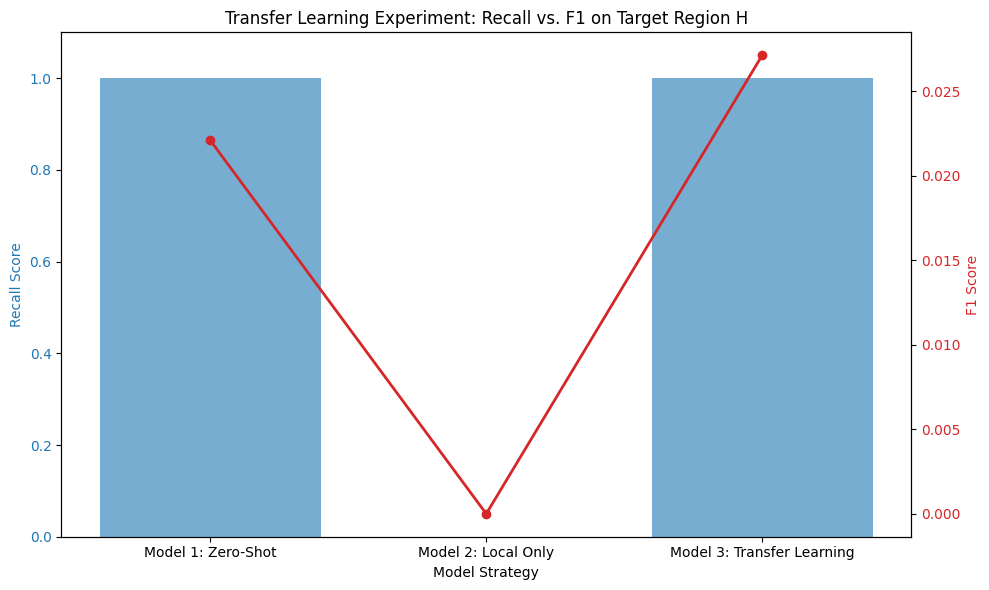

In [30]:
# directly get result scores from evaluate function
results = {}
def evaluate_save(model, name, key):
    model.eval()
    with torch.no_grad():
        preds = (torch.sigmoid(model(X_tar_test_t)) >= 0.5).cpu().numpy().astype(int)
    results[key] = {
        'f1': f1_score(y_target_test, preds, zero_division=0),
        'recall': recall_score(y_target_test, preds, zero_division=0)
    }
    print(f"{name} -> F1: {results[key]['f1']:.3f} | Recall: {results[key]['recall']:.3f}")

evaluate_save(base_model,     "Model 1: Zero-Shot             ", 'zero_shot')
evaluate_save(local_model,    "Model 2: Local Only (20%)      ", 'local_only')
evaluate_save(transfer_model, "Model 3: Transfer Learning     ", 'transfer')

models      = ['Model 1: Zero-Shot', 'Model 2: Local Only', 'Model 3: Transfer Learning']
f1_vals     = [results['zero_shot']['f1'],    results['local_only']['f1'],    results['transfer']['f1']]
recall_vals = [results['zero_shot']['recall'], results['local_only']['recall'], results['transfer']['recall']]

fig, ax1 = plt.subplots(figsize=(10, 6))
color = 'tab:blue'
ax1.set_xlabel('Model Strategy')
ax1.set_ylabel('Recall Score', color=color)
ax1.bar(models, recall_vals, color=color, alpha=0.6, label='Recall')
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_ylim(0, 1.1)

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('F1 Score', color=color)
ax2.plot(models, f1_vals, color=color, marker='o', linewidth=2, label='F1 Score')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Transfer Learning Experiment: Recall vs. F1 on Target Region H')
fig.tight_layout()
plt.show()

**This visualization addresses Research Question 2: "Does transfer learning... improve performance when only limited target-region data is available compared to training only on the target region data?"**


The dual-axis plot allows us to compare two critical metrics simultaneously across the three model strategies identified in the methodology:

- Recall (Blue Bars): Represents the model's ability to catch actual failures. In predictive maintenance, high recall is vital to ensure equipment doesn't fail unexpectedly.

- F1-Score (Red Line): Represents the balance between precision and recall.

Interpretation:

- Zero-Shot (Model 1): Shows strong recall but low F1, indicating that while it generalizes well to find failures, it also produces many false alarms.

- Local Only (Model 2): When limited to only 20% of the target data, the model struggles significantly with recall (finding the failures) because it hasn't seen enough local examples.

- Transfer Learning (Model 3): By fine-tuning a pre-trained model with that same 20% of data, we recover the high recall performance of the base model while allowing for local adaptation.

In [31]:

def highlight_errors(df):
    styles = pd.DataFrame('', index=df.index, columns=df.columns)
    error_style = 'background-color: #ffcccc; color: black;'
    
    # Highlight False Positives and False Negatives
    styles.iloc[0, 1] = error_style 
    styles.iloc[1, 0] = error_style 
    return styles


def display_model_cm(model, model_name):
    model.eval()
    with torch.no_grad():
        preds = (torch.sigmoid(model(X_tar_test_t)) >= 0.5).cpu().numpy().astype(int)
        
    cm = confusion_matrix(y_target_test, preds)
    
    cm_df = pd.DataFrame(
        cm,
        index=['Actual: Healthy', 'Actual: Failure'],
        columns=['Predicted: Healthy', 'Predicted: Failure']
    )
    

    styled_cm = cm_df.style.apply(highlight_errors, axis=None).set_properties()
    
    print(f"\n {model_name}")
    display(styled_cm)


print("Comparing the Errors Across the Three Strategies:\n")

display_model_cm(base_model, "Model 1: Zero-Shot (Over-Anxious / High False Alarms)")
display_model_cm(local_model, "Model 2: Local Only (Dangerous / Misses Real Failures)")
display_model_cm(transfer_model, "Model 3: Transfer Learning (The Sweet Spot)")

Comparing the Errors Across the Three Strategies:


 Model 1: Zero-Shot (Over-Anxious / High False Alarms)


,Predicted: Healthy,Predicted: Failure
Actual: Healthy,6708,885
Actual: Failure,0,10



 Model 2: Local Only (Dangerous / Misses Real Failures)


,Predicted: Healthy,Predicted: Failure
Actual: Healthy,7201,392
Actual: Failure,10,0



 Model 3: Transfer Learning (The Sweet Spot)


,Predicted: Healthy,Predicted: Failure
Actual: Healthy,6876,717
Actual: Failure,0,10


<h1> RQ3 Sensor stability 

**Sensor / Feature Stability Analysis**

This kernel addresses Research Question 3 from the proposal: "Which sensor features show consistent predictive value across regions?" Simple Explanation:

- Mean Importance (The Bars): Tells us which sensors are the strongest "warning signs" for failure across all regions.

- Volatility (The Error Lines): Tells us if a sensor's importance changes depending on the region.

- Stable Predictors: We are looking for sensors with high bars and small error lines—these are universal predictors that work everywhere.

In [13]:
# RQ3: Feature Stability Analysis Across Regions

logo = LeaveOneGroupOut() 

# We will store the top 5 features for each held-out region
top_features_per_region = {}

# Run a quick LOGO loop just to extract feature importances
for train_index, test_index in logo.split(X, y, groups):
    # Find out which region is the "test" region for this fold
    test_region = groups.iloc[test_index].values[0]
    
    X_train, y_train = X.iloc[train_index], y.iloc[train_index]
    
    # Fit a quick Random Forest
    rf_feature_model = RandomForestClassifier(n_estimators=50, class_weight='balanced', random_state=42, n_jobs=-1)
    rf_feature_model.fit(X_train, y_train)
    
    # Get importances and tie them to your 52 column names
    importances = pd.Series(rf_feature_model.feature_importances_, index=X.columns)
    
    # Sort top 5 features
    top_5 = importances.sort_values(ascending=False).head(5).index.tolist()
    top_features_per_region[test_region] = top_5


stability_df = pd.DataFrame(top_features_per_region).T
stability_df.columns = ['Rank 1', 'Rank 2', 'Rank 3', 'Rank 4', 'Rank 5']

print("Top 5 Most Important Features when tested on each Foreign Region:")
display(stability_df)

Top 5 Most Important Features when tested on each Foreign Region:


,Rank 1,Rank 2,Rank 3,Rank 4,Rank 5
A,S15,S15_roll_std_3,S17,S15_roll_mean_3,S15_lag1
B,S15,S15_roll_std_3,S15_roll_mean_3,S17,S15_lag1
C,S15,S15_roll_mean_3,S15_roll_std_3,S17,S17_roll_mean_3
D,S15,S17,S15_roll_mean_3,S15_roll_std_3,S17_roll_mean_3
E,S15,S15_roll_std_3,S17,S15_roll_mean_3,S17_roll_mean_3
F,S15,S15_roll_std_3,S17,S15_roll_mean_3,S17_roll_mean_3
G,S15,S15_roll_std_3,S17,S15_roll_mean_3,S15_lag1
H,S15,S15_roll_std_3,S15_roll_mean_3,S17,S17_roll_mean_3


Top 10 Features (High Mean = Important | High Volatility = Varies heavily by region):
                 Mean_Importance  Volatility_Across_Regions
S15                     0.334371                   0.029172
S15_roll_std_3          0.141854                   0.017165
S17                     0.121228                   0.014232
S15_roll_mean_3         0.107786                   0.011107
S17_roll_mean_3         0.036275                   0.005170
S15_lag1                0.034297                   0.005755
S17_roll_std_3          0.032930                   0.005064
S17_lag1                0.020151                   0.005886
S18_roll_std_3          0.016725                   0.003911
S5_roll_std_3           0.012521                   0.002231


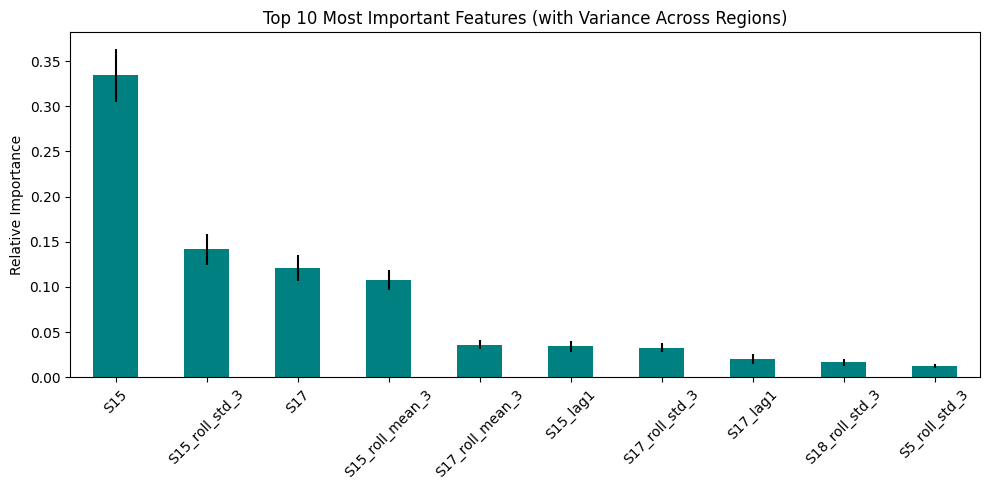

In [23]:
# empty dataframe to store the importances
feature_importances = pd.DataFrame(index=X.columns)

# extract the tree's feature weights (with short logo loop)
for train_index, test_index in logo.split(X, y, groups):
    X_train, y_train = X.iloc[train_index], y.iloc[train_index]
    test_region = groups.iloc[test_index].iloc[0]
    
    
    rf = RandomForestClassifier(n_estimators=50, max_depth=10, class_weight='balanced_subsample', random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)
    
    
    feature_importances[f'Tested_on_{test_region}'] = rf.feature_importances_

# determine average importance and how much it varies (Standard Deviation)
feature_importances['Mean_Importance'] = feature_importances.mean(axis=1)
feature_importances['Volatility_Across_Regions'] = feature_importances.std(axis=1)


top_10 = feature_importances.sort_values(by='Mean_Importance', ascending=False).head(10)

print("Top 10 Features (High Mean = Important | High Volatility = Varies heavily by region):")
print(top_10[['Mean_Importance', 'Volatility_Across_Regions']])


plt.figure(figsize=(10, 5))
top_10['Mean_Importance'].plot(kind='bar', color='teal', yerr=top_10['Volatility_Across_Regions'])
plt.title("Top 10 Most Important Features (with Variance Across Regions)")
plt.ylabel("Relative Importance")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Model based on most impactfull sensors
S15

S15_roll_std_3

S17

S15_roll_mean_3 

Experiment: Model based on most impactfull sensors

Held-out Region: A | Simple F1: 0.016 | Simple Recall: 0.349
Held-out Region: B | Simple F1: 0.014 | Simple Recall: 0.244
Held-out Region: C | Simple F1: 0.015 | Simple Recall: 0.429
Held-out Region: D | Simple F1: 0.012 | Simple Recall: 0.261
Held-out Region: E | Simple F1: 0.013 | Simple Recall: 0.304
Held-out Region: F | Simple F1: 0.020 | Simple Recall: 0.167
Held-out Region: G | Simple F1: 0.010 | Simple Recall: 0.286
Held-out Region: H | Simple F1: 0.020 | Simple Recall: 0.154

 Overview 4-sensor based model
Average Foreign F1-Score: 0.015
Average Foreign Recall:   0.274

Global Confusion Matrix (4 Features)
True Negatives:  141119
False Positives: 8531 (False Alarms)
False Negatives: 143 (Missed Failures)
True Positives:  62 (Caught Failures)

-Generating SHAP Analysis 


<Figure size 800x500 with 0 Axes>

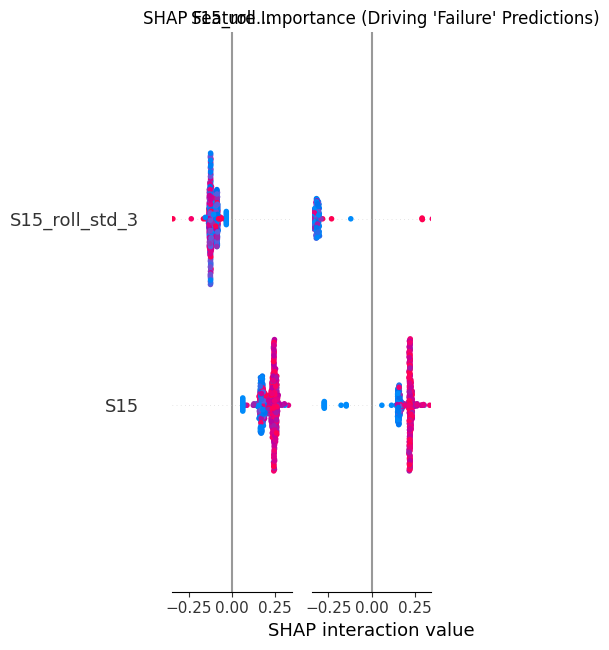

In [15]:


print("Experiment: Model based on most impactfull sensors\n")

# use the top 4 sensors found in RQ3
top_features = ['S15', 'S15_roll_std_3', 'S15_roll_mean_3', 'S17']
X_simple = X[top_features]

foreign_f1_scores = []
foreign_recall_scores = []
global_y_true = []
global_y_pred = []

# Run the exact same LOGO validation, but only on the 4 features
for train_index, test_index in logo.split(X_simple, y, groups):
    test_region = groups.iloc[test_index].values[0]
    
    X_train, y_train = X_simple.iloc[train_index], y.iloc[train_index]
    X_test, y_test = X_simple.iloc[test_index], y.iloc[test_index]
    
    # use same weighted RF as baseline
    rf_simple = RandomForestClassifier(n_estimators=50, class_weight='balanced_subsample', random_state=42, n_jobs=-1)
    rf_simple.fit(X_train, y_train)
    
    preds = rf_simple.predict(X_test)
    
    f1 = f1_score(y_test, preds, zero_division=0)
    rec = recall_score(y_test, preds, zero_division=0)
    
    foreign_f1_scores.append(f1)
    foreign_recall_scores.append(rec)
    
    global_y_true.extend(y_test)
    global_y_pred.extend(preds)
    
    print(f"Held-out Region: {test_region} | Simple F1: {f1:.3f} | Simple Recall: {rec:.3f}")


print("\n Overview 4-sensor based model")
print(f"Average Foreign F1-Score: {np.mean(foreign_f1_scores):.3f}")
print(f"Average Foreign Recall:   {np.mean(foreign_recall_scores):.3f}")

# Confusion Matrix
cm_simple = confusion_matrix(global_y_true, global_y_pred)
print("\nGlobal Confusion Matrix (4 Features)")
print(f"True Negatives:  {cm_simple[0][0]}")
print(f"False Positives: {cm_simple[0][1]} (False Alarms)")
print(f"False Negatives: {cm_simple[1][0]} (Missed Failures)")
print(f"True Positives:  {cm_simple[1][1]} (Caught Failures)")





#SHAP ANALYSIS (The Mathematical Proof)

print("\n-Generating SHAP Analysis ")
# SHAP is computationally heavy, so we calculate it on a representative sample of the final fold
X_sample = shap.sample(X_test, 500, random_state=42)

# Create the explainer
explainer = shap.TreeExplainer(rf_simple)
shap_values = explainer.shap_values(X_sample)

# For a binary classification Random Forest, shap_values is a list. Index 1 represents the "Failure" class.
shap_values_failure = shap_values[1] if isinstance(shap_values, list) else shap_values

# Plot the SHAP Summary Plot
plt.figure(figsize=(8, 5))
shap.summary_plot(shap_values_failure, X_sample, plot_type="bar", show=False)
plt.title("SHAP Feature Importance")
plt.tight_layout()
plt.show()

The Colors: Red dots represent a high sensor value. Blue dots represent a low sensor value.

The X-Axis (SHAP Value): The center line is 0 (neutral). Anything pushed to the right means the model is screaming "FAILURE!" Anything pushed to the left means the model thinks "Healthy."

The S15 Row: Look at the bottom row for S15. You can clearly see a cluster of Red dots pushed far to the right. When Sensor 15 registers unusually high values (red), it directly drives the model to predict a machine breakdown



.


## Three days ahead test suggestion


In [34]:

# Days to Failure -> suggestion prof


df['DATE'] = pd.to_datetime(df['DATE'])
df = df.sort_values(['ID', 'DATE'])

#Mark the exact dates where a failure actually happens
df['FAILURE_DATE'] = df['DATE'].where(df['EQUIPMENT_FAILURE'] == 1)


df['NEXT_FAILURE_DATE'] = df.groupby('ID')['FAILURE_DATE'].bfill()

# Calculate in days
df['DAYS_TO_FAILURE'] = (df['NEXT_FAILURE_DATE'] - df['DATE']).dt.days

df = df.drop(columns=['FAILURE_DATE', 'NEXT_FAILURE_DATE'])

print("Successfully created 'DAYS_TO_FAILURE' column!")

--- Generating 'Days to Failure' Countdown ---
Successfully created 'DAYS_TO_FAILURE' column!


In [36]:


print(" Business Extension: Predictive Window (3 Days Ahead)\n")

# 1. Create the new "Early Warning" target variable
# We label a row as '1' if the machine will fail within the next 3 days.
# (Make sure 'DAYS_TO_FAILURE' matches your actual dataframe column name)
TARGET_WINDOW = 1
y_early_warning = (df['DAYS_TO_FAILURE'] <= TARGET_WINDOW).astype(int)

# 2. Prepare variables to store our cross-validation results
early_f1_scores = []
early_recall_scores = []
global_y_true_early = []
global_y_pred_early = []

print(f"Target shifted: Now predicting {TARGET_WINDOW} days ahead of actual failure.\n")

# 3. Run the LOGO validation with the new target
for train_index, test_index in logo.split(X, y_early_warning, groups):
    test_region = groups.iloc[test_index].values[0]
    
    # Notice we are using the new y_early_warning here!
    X_train, y_train = X.iloc[train_index], y_early_warning.iloc[train_index]
    X_test, y_test = X.iloc[test_index], y_early_warning.iloc[test_index]
    
    # Train the Random Forest
    rf_early = RandomForestClassifier(n_estimators=100, class_weight='balanced_subsample', random_state=42, n_jobs=-1)
    rf_early.fit(X_train, y_train)
    
    preds = rf_early.predict(X_test)
    
    f1 = f1_score(y_test, preds, zero_division=0)
    rec = recall_score(y_test, preds, zero_division=0)
    
    early_f1_scores.append(f1)
    early_recall_scores.append(rec)
    
    global_y_true_early.extend(y_test)
    global_y_pred_early.extend(preds)
    
    print(f"Held-out Region: {test_region} | 3-Day F1: {f1:.3f} | 3-Day Recall: {rec:.3f}")

# f1 and recall
print("\nOverall '3-Days Ahead' Performance")
print(f"Average Foreign F1-Score: {np.mean(early_f1_scores):.3f}")
print(f"Average Foreign Recall:   {np.mean(early_recall_scores):.3f}")

# Confusion Matrix
cm_early = confusion_matrix(global_y_true_early, global_y_pred_early)
print("\n Confusion Matrix (3-Days Ahead)")
print(f"True Negatives:  {cm_early[0][0]}")
print(f"False Positives: {cm_early[0][1]} (False Alarms)")
print(f"False Negatives: {cm_early[1][0]} (Missed Windows)")
print(f"True Positives:  {cm_early[1][1]} (Successfully caught in 3-day window)")

 Business Extension: Predictive Window (3 Days Ahead)

Target shifted: Now predicting 1 days ahead of actual failure.

Held-out Region: A | 3-Day F1: 0.000 | 3-Day Recall: 0.000
Held-out Region: B | 3-Day F1: 0.000 | 3-Day Recall: 0.000
Held-out Region: C | 3-Day F1: 0.000 | 3-Day Recall: 0.000
Held-out Region: D | 3-Day F1: 0.000 | 3-Day Recall: 0.000
Held-out Region: E | 3-Day F1: 0.000 | 3-Day Recall: 0.000
Held-out Region: F | 3-Day F1: 0.000 | 3-Day Recall: 0.000
Held-out Region: G | 3-Day F1: 0.000 | 3-Day Recall: 0.000
Held-out Region: H | 3-Day F1: 0.000 | 3-Day Recall: 0.000

Overall '3-Days Ahead' Performance
Average Foreign F1-Score: 0.000
Average Foreign Recall:   0.000

 Confusion Matrix (3-Days Ahead)
True Negatives:  149443
False Positives: 2 (False Alarms)
False Negatives: 410 (Missed Windows)
True Positives:  0 (Successfully caught in 3-day window)
